In [1]:
##USE conda environment tf
# conda activate tf

import anndata as ad
import scanpy as sc
from matplotlib import rcParams
import pandas as pd
import h5py
import IPython
import bardensr.plotting
import numpy as np
import SimpleITK as sitk
import numpy as np
import tensorflow as tf
import bardensr.preprocessing
import harmonypy

2026-07-13 12:40:08.623757: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-13 12:40:08.638604: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783960808.656219 3524258 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783960808.661662 3524258 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-13 12:40:08.680555: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
import numpy as np

def rotate_points(spatial, theta):
    # Define the rotation matrix
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])
    
    # Rotate the points
    rotated_points = spatial @ rotation_matrix.T
    
    return rotated_points

# Example usage
# Create a set of points (for example)
spatial = np.array([[1, 0], [0, 1], [-1, 0], [0, -1]])

# Define the rotation angle (in radians)
theta = np.pi / 4  # 45 degrees

# Rotate the points
rotated_spatial = rotate_points(spatial, theta)
print(rotated_spatial)

def open_hdf5(file_path): #assumes this is a list of np arrays
    var_name= []
    f = h5py.File(file_path)
    print(f)
    data = f['list']
    for i in range(len(data)):
        var_name.append(data[str(i)][:])
    f.close()
    print(len(var_name))
    print(len(var_name[0]))
    return var_name

[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]
 [-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]


/tmp/ipykernel_3524258/4233458260.py:18: ImplicitModificationWarning: Setting element `.obsm['spatial3d']` of view, initializing view as actual.
  p4_1_corr.obsm['spatial3d'] = np.zeros([len(p4_1_corr),3])


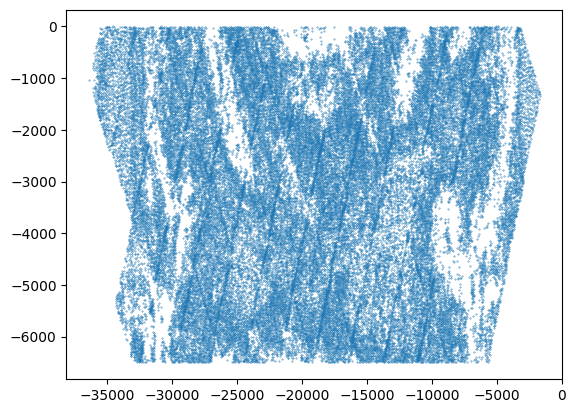

In [3]:
import matplotlib.pyplot as plt

p4_1 = ad.read_h5ad("../../../mouse/p4/ma34_p4_b1/output/adata.h5ad")
p4_1.obs['library_id'] = 'p4_1'
p4_1.obs['timepoint'] = 'p4'
p4_1.obs['batch'] = 'batch3'

p4_1.obsm['spatial'] = rotate_points(p4_1.obsm['spatial'], (140/180)*3.14)
p4_1_coor = p4_1.obsm['spatial'][p4_1.obsm['spatial'][:,1] <0]
p4_1_coor = p4_1_coor[p4_1_coor[:,1] >-6500]
plt.scatter(p4_1_coor[:,0], p4_1_coor[:,1], s=0.1)

# Convert e13_1_coor to a list of tuples for faster lookups
p4_1_coor_set = {tuple(coord) for coord in p4_1_coor}
mask = np.array([tuple(coord) in p4_1_coor_set for coord in p4_1.obsm['spatial']])
p4_1_corr = p4_1[mask]

p4_1_corr.obsm['spatial3d'] = np.zeros([len(p4_1_corr),3])
x = p4_1_corr.obsm['spatial'][:,0]
y = p4_1_corr.obsm['spatial'][:,1]
p4_1_corr.obsm['spatial'][:,0] = (x - np.min(x))
p4_1_corr.obsm['spatial'][:,1] = (y - np.min(y))
p4_1_corr.obsm['spatial3d'][:,0] = (x - np.min(x))
p4_1_corr.obsm['spatial3d'][:,1] = (y - np.min(y))
p4_1_corr.obsm['spatial3d'][:,2] = 0

/tmp/ipykernel_3524258/2209906384.py:18: ImplicitModificationWarning: Setting element `.obsm['spatial3d']` of view, initializing view as actual.
  p4_2_corr.obsm['spatial3d'] = np.zeros([len(p4_2_corr),3])


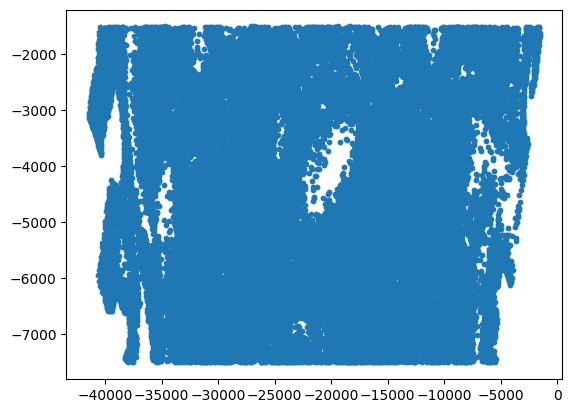

In [4]:
import matplotlib.pyplot as plt

p4_2 = ad.read_h5ad("../../../mouse/p4/ma34_p4_b3/output/adata.h5ad")
p4_2.obs['library_id'] = 'p4_2'
p4_2.obs['timepoint'] = 'p4'
p4_2.obs['batch'] = 'batch3'

p4_2.obsm['spatial'] = rotate_points(p4_2.obsm['spatial'], (148/180)*3.14)
p4_2_coor = p4_2.obsm['spatial'][p4_2.obsm['spatial'][:,1] <-1500]
p4_2_coor = p4_2_coor[p4_2_coor[:,1] >-7500]
plt.scatter(p4_2_coor[:,0], p4_2_coor[:,1], s=10)

# Convert e13_1_coor to a list of tuples for faster lookups
p4_2_coor_set = {tuple(coord) for coord in p4_2_coor}
mask = np.array([tuple(coord) in p4_2_coor_set for coord in p4_2.obsm['spatial']])
p4_2_corr = p4_2[mask]

p4_2_corr.obsm['spatial3d'] = np.zeros([len(p4_2_corr),3])
x = p4_2_corr.obsm['spatial'][:,0]
y = p4_2_corr.obsm['spatial'][:,1]
p4_2_corr.obsm['spatial'][:,0] = (x - np.min(x))
p4_2_corr.obsm['spatial'][:,1] = (y - np.min(y))+ 20000
p4_2_corr.obsm['spatial3d'][:,0] = (x - np.min(x))
p4_2_corr.obsm['spatial3d'][:,1] = (y - np.min(y))
p4_2_corr.obsm['spatial3d'][:,2] = 0

/tmp/ipykernel_3524258/3564073478.py:18: ImplicitModificationWarning: Setting element `.obsm['spatial3d']` of view, initializing view as actual.
  p4_3_corr.obsm['spatial3d'] = np.zeros([len(p4_3_corr),3])


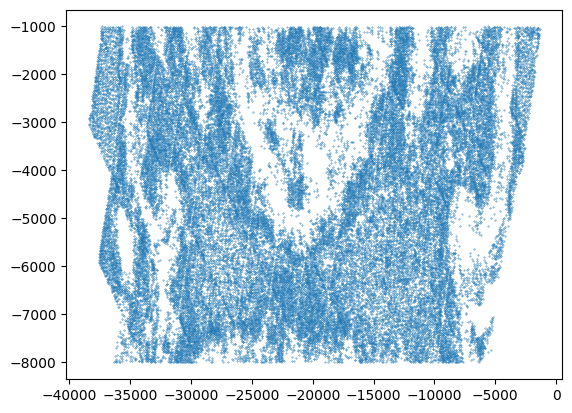

In [5]:
import matplotlib.pyplot as plt

p4_3 = ad.read_h5ad("../../../mouse/p4/ma34_p4_b5/output/adata.h5ad")
p4_3.obs['library_id'] = 'p4_3'
p4_3.obs['timepoint'] = 'p4'
p4_3.obs['batch'] = 'batch3'

p4_3.obsm['spatial'] = rotate_points(p4_3.obsm['spatial'], (149/180)*3.14)
p4_3_coor = p4_3.obsm['spatial'][p4_3.obsm['spatial'][:,1] <-1000]
p4_3_coor = p4_3_coor[p4_3_coor[:,1] >-8000]
plt.scatter(p4_3_coor[:,0], p4_3_coor[:,1], s=0.1)
 
# Convert e13_1_coor to a list of tuples for faster lookups
p4_3_coor_set = {tuple(coord) for coord in p4_3_coor}
mask = np.array([tuple(coord) in p4_3_coor_set for coord in p4_3.obsm['spatial']])
p4_3_corr = p4_3[mask]

p4_3_corr.obsm['spatial3d'] = np.zeros([len(p4_3_corr),3])
x = p4_3_corr.obsm['spatial'][:,0]
y = p4_3_corr.obsm['spatial'][:,1]
p4_3_corr.obsm['spatial'][:,0] = (x - np.min(x))
p4_3_corr.obsm['spatial'][:,1] = (y - np.min(y))+ 20000*2
p4_3_corr.obsm['spatial3d'][:,0] = (x - np.min(x))
p4_3_corr.obsm['spatial3d'][:,1] = (y - np.min(y))
p4_3_corr.obsm['spatial3d'][:,2] = 0

/tmp/ipykernel_3524258/3463961534.py:18: ImplicitModificationWarning: Setting element `.obsm['spatial3d']` of view, initializing view as actual.
  p4_4_corr.obsm['spatial3d'] = np.zeros([len(p4_4_corr),3])


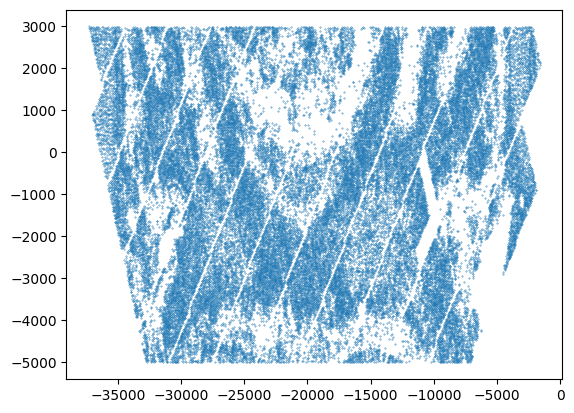

In [6]:
import matplotlib.pyplot as plt

p4_4 = ad.read_h5ad("../../../mouse/p4/ma34_p4_b6/output/adata.h5ad")
p4_4.obs['library_id'] = 'p4_4'
p4_4.obs['timepoint'] = 'p4'
p4_4.obs['batch'] = 'batch3'

p4_4.obsm['spatial'] = rotate_points(p4_4.obsm['spatial'], (126/180)*3.14)
p4_4_coor = p4_4.obsm['spatial'][p4_4.obsm['spatial'][:,1] <3000]
p4_4_coor = p4_4_coor[p4_4_coor[:,1] >-5000]
plt.scatter(p4_4_coor[:,0], p4_4_coor[:,1], s=0.1)
 
# Convert e13_1_coor to a list of tuples for faster lookups
p4_4_coor_set = {tuple(coord) for coord in p4_4_coor}
mask = np.array([tuple(coord) in p4_4_coor_set for coord in p4_4.obsm['spatial']])
p4_4_corr = p4_4[mask]

p4_4_corr.obsm['spatial3d'] = np.zeros([len(p4_4_corr),3])
x = p4_4_corr.obsm['spatial'][:,0]
y = p4_4_corr.obsm['spatial'][:,1]
p4_4_corr.obsm['spatial'][:,0] = (x - np.min(x))
p4_4_corr.obsm['spatial'][:,1] = (y - np.min(y))+ 20000*3
p4_4_corr.obsm['spatial3d'][:,0] = (x - np.min(x))
p4_4_corr.obsm['spatial3d'][:,1] = (y - np.min(y))
p4_4_corr.obsm['spatial3d'][:,2] = 0

In [7]:
def combine_and_rename_genes(adata, unwanted_genes):
    """
    Combine gene names with colons into their base names, summing duplicates,
    and filter out unwanted genes from the AnnData object.

    Parameters:
    adata: AnnData object containing gene expression data.
    unwanted_genes: List of gene names to exclude from the final result.

    Returns:
    AnnData object with updated gene names and filtered data.
    """
    gene_sums = {}
    # Iterate through the var_names to process them
    for var_name in adata.var_names:
        if ':' in var_name:
            # Get the base name before the colon
            base_name = var_name.split(':')[0]
            if base_name in gene_sums:
                # Sum the values for duplicates
                gene_sums[base_name] += adata[:, var_name].X
            else:
                # Initialize with the current values
                gene_sums[base_name] = adata[:, var_name].X
        else:
            # Copy over values for non-colon names
            if var_name not in gene_sums:
                gene_sums[var_name] = adata[:, var_name].X

    # Update var_names and the X values in the AnnData object
    new_var_names = list(gene_sums.keys())
    new_X = np.array(list(gene_sums.values()))
    print(new_X.shape)
    # Assign the updated names and values back to the AnnData object
    adata_new = ad.AnnData(new_X[:,:,0].T)
    adata_new.var_names = new_var_names
    adata_new.obs = adata.obs
    #adata_new.var = adata.var
    adata_new.obsm = adata.obsm

    #adata_new.var_names = new_var_names
    #adata_new.X = new_X

    # Filter out unwanted genes
    gene_list = [gene for gene in adata_new.var_names if gene not in unwanted_genes]
    adata_new = adata_new[:, gene_list]

    return adata_new

# Example usage:
# e11_sub = combine_and_rename_genes(e11_sub, ["Slc17a7", "Atf4", "Rex2", "Lamc1", "Sema3c", "Hoxd3", "Sox15", "Slit3"])

In [8]:
adata = ad.concat([p4_1_corr, p4_2_corr, p4_3_corr, p4_4_corr])
adata.obs = adata.obs.reset_index(drop=True)


/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [9]:
p4_alltp = sc.read_h5ad("../all_tp/p4_2_all_tp_ct.h5ad")

mapping = p4_alltp.obs.set_index("cell_number")["cell_types"]

p4_2_corr.obs["cell_types"] = mapping.reindex(p4_2_corr.obs_names)

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


predicted_cell_types
Glia/Oligodendrocytes             87440
Granule cells                     49636
Purkinje Cells                    14559
Outside Cb                        14197
Molecular Layer Interneurons      10353
Midbrain-derived + Int/Lat DCN     3228
Choroid Plexus                     2202
i1                                 1577
Midbrain-fated cells               1235
Astroglia                           895
Medial DCN                          546
Name: count, dtype: int64
count    185868.000000
mean          0.680939
std           0.208926
min           0.138681
25%           0.526451
50%           0.670013
75%           0.866997
max           1.000000
Name: predicted_max_prob, dtype: float64


/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scipy/sparse/_index.py:146: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


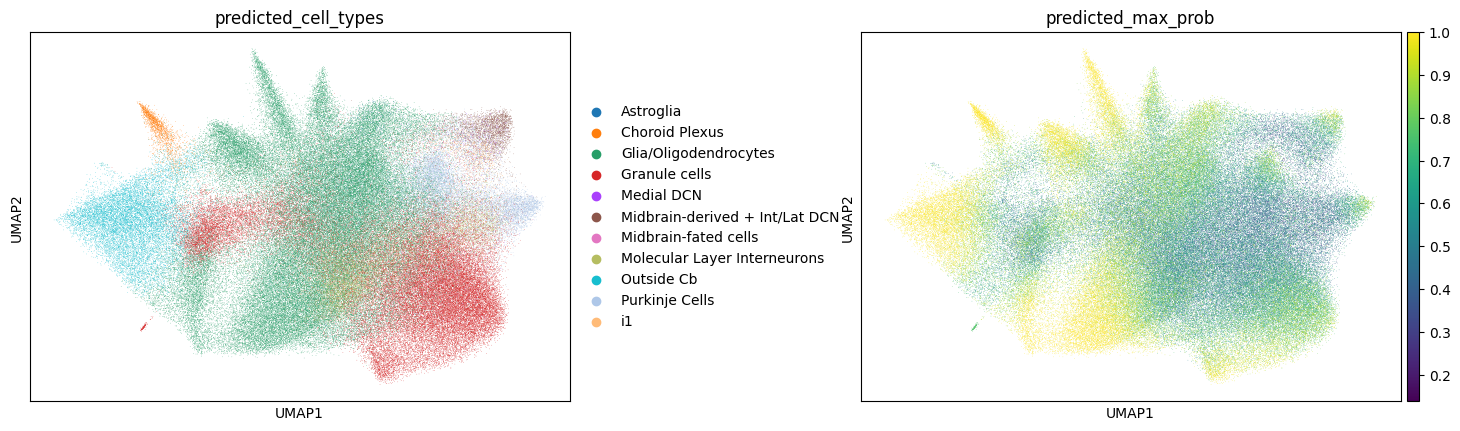

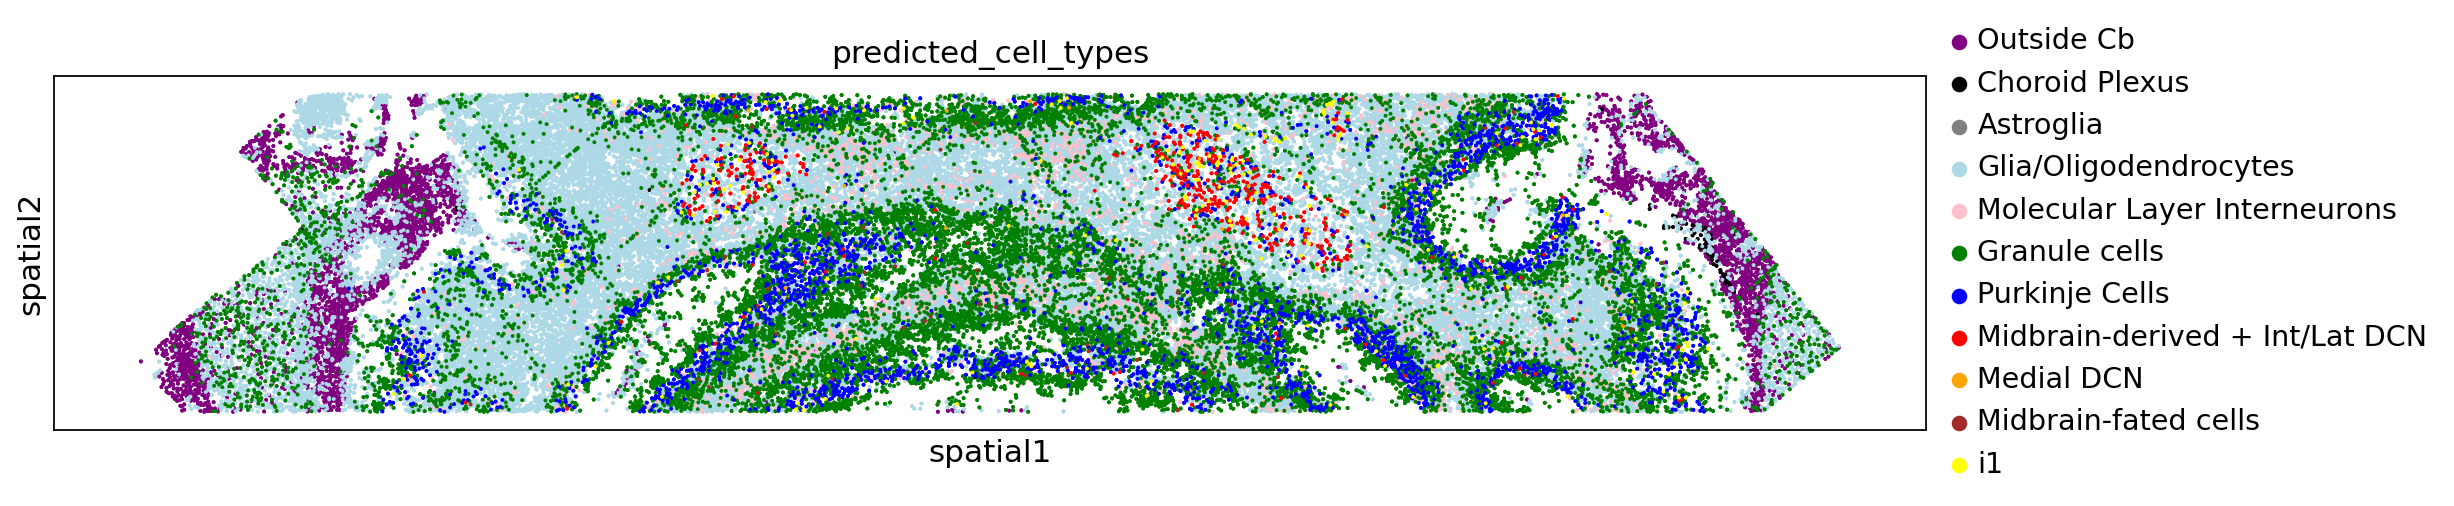

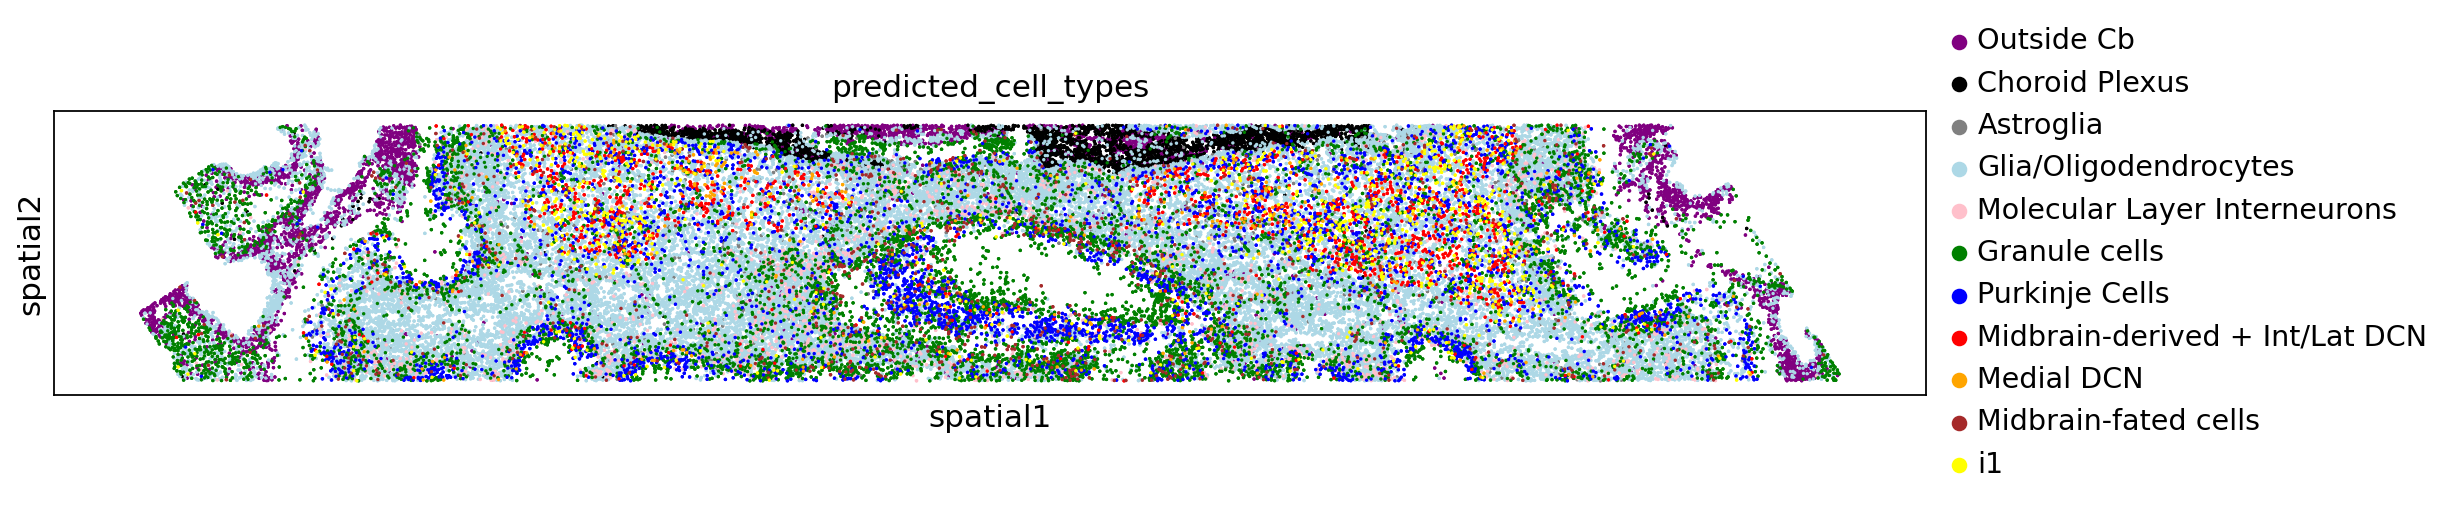

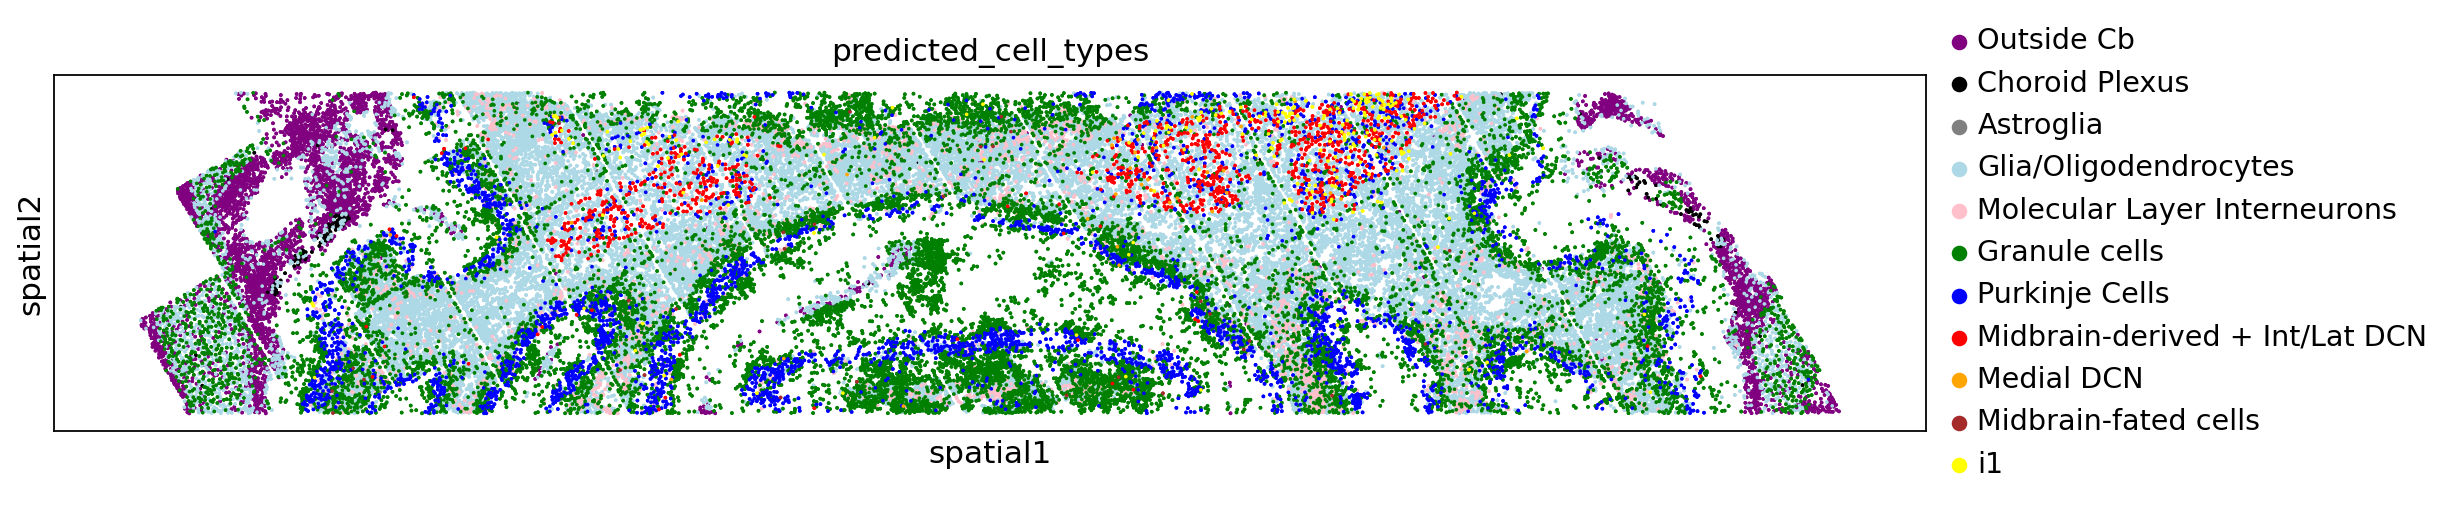

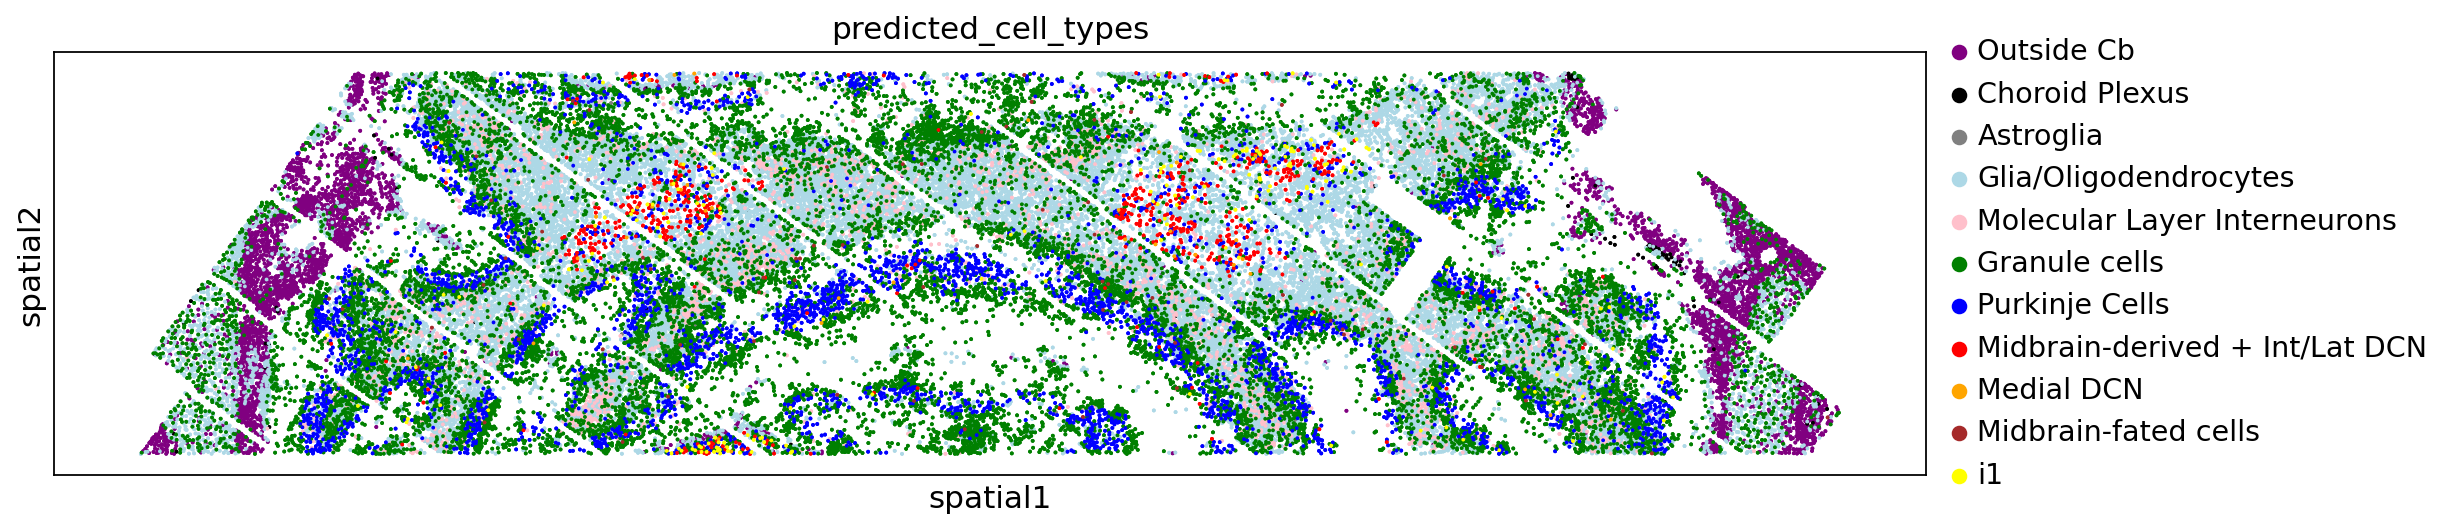

In [10]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.neighbors import KNeighborsClassifier
from scipy import sparse

# =========================================================
# 1. PREP REFERENCE + QUERY
# =========================================================
ref = p4_2_corr.copy()
query = adata.copy()

# keep only labeled ref cells
ref = ref[~ref.obs["cell_types"].isna()].copy()
ref.obs["cell_types"] = pd.Categorical(
    ref.obs["cell_types"].astype(str)
).remove_unused_categories()

# shared genes, same order
shared = ref.var_names.intersection(query.var_names)
ref = ref[:, shared].copy()
query = query[:, shared].copy()

# normalize + log
for x in [ref, query]:
    sc.pp.normalize_total(x)
    sc.pp.log1p(x)

# HVGs from reference only
sc.pp.highly_variable_genes(ref, n_top_genes=3000, flavor="seurat")
hvg = ref.var["highly_variable"].values

ref = ref[:, hvg].copy()
query = query[:, hvg].copy()

# dense matrices if needed
X_ref = ref.X.toarray() if sparse.issparse(ref.X) else np.asarray(ref.X)
X_query = query.X.toarray() if sparse.issparse(query.X) else np.asarray(query.X)

# =========================================================
# 2. SCALE USING REFERENCE STATS
# =========================================================
ref_means = X_ref.mean(axis=0)
ref_stds = X_ref.std(axis=0)
ref_stds[ref_stds == 0] = 1

X_ref_scaled = (X_ref - ref_means) / ref_stds
X_query_scaled = (X_query - ref_means) / ref_stds

ref.X = X_ref_scaled
query.X = X_query_scaled

# =========================================================
# 3. PCA ON REFERENCE, PROJECT QUERY INTO SAME PC SPACE
# =========================================================
sc.tl.pca(ref, n_comps=30)

X_ref_pca = ref.obsm["X_pca"]
loadings = ref.varm["PCs"][:, :30]   # genes x PCs
X_query_pca = X_query_scaled @ loadings

ref.obsm["X_pca_ref"] = X_ref_pca
query.obsm["X_pca_ref"] = X_query_pca

# =========================================================
# 4. KNN LABEL TRANSFER IN PC SPACE
# =========================================================
y_ref = ref.obs["cell_types"].astype(str).values

knn = KNeighborsClassifier(n_neighbors=15, weights="distance")
knn.fit(X_ref_pca, y_ref)

pred = knn.predict(X_query_pca)
probs = knn.predict_proba(X_query_pca)

query.obs["predicted_cell_types"] = pred
query.obs["predicted_max_prob"] = probs.max(axis=1)

# optional: reject low-confidence cells
threshold = 0.0
query.obs["predicted_cell_types"] = np.where(
    query.obs["predicted_max_prob"] < threshold,
    "Unknown",
    query.obs["predicted_cell_types"]
)

query.obs["predicted_cell_types"] = pd.Categorical(query.obs["predicted_cell_types"])

# quick checks
print(query.obs["predicted_cell_types"].value_counts())
print(query.obs["predicted_max_prob"].describe())


# =========================================================
# 5. OPTIONAL UMAP OF TRANSFERRED LABELS
# =========================================================
sc.pp.neighbors(query, use_rep="X_pca_ref", n_neighbors=15)
sc.tl.umap(query)

sc.pl.umap(
    query,
    color=["predicted_cell_types", "predicted_max_prob"],
    wspace=0.4
)

# =========================================================
# 6. COLOR MAP + PLOTTING STYLE
# =========================================================
custom_colors = {
    "Purkinje Cells": "blue",
    "Midbrain-derived + Int/Lat DCN": "red",
    "Medial DCN": "orange",
    "DCN": "orange",
    "Astroglia": "grey",
    "": "white",
    "Choroid Plexus": "black",
    "Granule cells": "green",
    "Midbrain-fated cells": "brown",
    "Molecular Layer Interneurons": "pink",
    "Outside Cb": "purple",
    "Glia/Oligodendrocytes": "lightblue",
    "i1": "yellow",
    "Unknown": "#BBBBBB",
}

desired_order = [
    "Outside Cb",
    "Choroid Plexus",
    "Astroglia",
    "Glia/Oligodendrocytes",
    "Molecular Layer Interneurons",
    "Granule cells",
    "DCN",
    "Purkinje Cells",
    "",
    "Midbrain-derived + Int/Lat DCN",
    "Medial DCN",
    "Midbrain-fated cells",
    "i1",
    "Unknown",
]

to_plot = [
    ("p4_1",  80,  "all_tp_e11"),
    ("p4_2",  80,  "all_tp_e11"),
    ("p4_3",  80,  "all_tp_e11"),
    ("p4_4",  80,  "all_tp_e11")
]

def set_colors(adata, key, color_map):
    adata.obs[key] = adata.obs[key].astype("category")
    cats = list(adata.obs[key].cat.categories)

    color_map = dict(color_map)
    for c in cats:
        if c not in color_map:
            color_map[c] = "#CCCCCC"

    adata.uns[f"{key}_colors"] = [mcolors.to_hex(color_map[c]) for c in cats]

def set_order(adata, key, desired_order):
    ct = adata.obs[key].astype("category")
    cur = list(ct.cat.categories)
    final_order = [c for c in desired_order if c in cur] + [c for c in cur if c not in desired_order]

    color_by_cat = dict(zip(cur, adata.uns[f"{key}_colors"]))
    adata.uns[f"{key}_colors"] = [color_by_cat[c] for c in final_order]
    adata.obs[key] = ct.cat.reorder_categories(final_order, ordered=True)

def spatial_overlay_in_order(
    ad, color="predicted_cell_types", order=None, spot_size=80,
    legend_loc="right margin", save=None, show=True
):
    ad.obs[color] = ad.obs[color].astype("category")

    cats_present = [c for c in ad.obs[color].cat.categories if (ad.obs[color] == c).any()]
    draw_order = [c for c in (order or cats_present) if c in cats_present]

    if not draw_order:
        print("[warn] no matching categories in this slice; drawing base only")
        sc.pl.spatial(ad, color=color, spot_size=spot_size, show=show)
        return

    # base layer
    sc.pl.spatial(
        ad,
        color=color,
        spot_size=spot_size,
        na_color="#DDDDDD",
        legend_loc=None,
        show=False
    )
    ax = plt.gca()

    # overlay each category in chosen order
    for g in draw_order:
        sc.pl.spatial(
            ad,
            color=color,
            groups=[g],
            spot_size=spot_size,
            na_color="none",
            ax=ax,
            legend_loc=None,
            title=None,
            show=False
        )

    # legend pass
    sc.pl.spatial(
        ad,
        color=color,
        spot_size=0,
        ax=ax,
        legend_loc=legend_loc,
        na_in_legend=False,
        show=False
    )

    if save:
        plt.savefig(save, bbox_inches="tight", dpi=300)
    if show:
        plt.show()
    plt.close()

# apply colors + order once to full query object
set_colors(query, "predicted_cell_types", custom_colors)
set_order(query, "predicted_cell_types", desired_order)

# =========================================================
# 7. PLOT ALL SLICES WITH SAME COLORS/ORDER
# =========================================================
sc.set_figure_params(figsize=(15, 5))

for lib_id, spot, suffix in to_plot:
    ad = query[query.obs["library_id"] == lib_id].copy()
    if ad.n_obs == 0:
        print(f"[warn] No cells for library_id={lib_id}, skipping")
        continue

    # preserve full global category order + colors
    ad.obs["predicted_cell_types"] = ad.obs["predicted_cell_types"].cat.set_categories(
        query.obs["predicted_cell_types"].cat.categories,
        ordered=True
    )
    ad.uns["predicted_cell_types_colors"] = query.uns["predicted_cell_types_colors"]

    spatial_overlay_in_order(
        ad,
        color="predicted_cell_types",
        order=desired_order,
        spot_size=spot,
        show=True,
        # save=f"{suffix}_predicted_overlay.pdf",
    )
